<table class="table table-bordered">
    <tr>
        <th style="text-align:center; vertical-align: middle; width:50%"><img src='https://www.np.edu.sg/_next/image?url=https%3A%2F%2Fassets.app.optical.gov.sg%2Fnp%2Fproduction%2Fpublished%2Fcollections%2Fpages%2F17c64bb4-8632-49e9-af16-047f7cabe99a%2Fab16008f-a6a0-466e-9193-e16e947261b0.png&w=640&q=75'"></th>
        <th style="text-align:center;"><h1>Deep Learning</h1><h2>Assignment - Food Classification Model (Individual)</h2><h3>AY2026/27 Semester</h3>
        <h3>Model 2 - Utilising pre-trained models</h3></th>
    </tr>
</table>

<h4>Student Name: NG CHEE WEE (3303451Y)</h4>

## Model 2a  - Using a pre-trained convnet

In [1]:
import tensorflow as tf
from keras.applications import MobileNetV2
from keras.applications.mobilenet_v2 import preprocess_input
from keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import os

I0000 00:00:1778571598.911253   70240 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778571598.971017   70240 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778571600.771114   70240 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [3]:
IMG_SIZE    = (224, 224)   # MobileNetV2 expects 224x224
BATCH_SIZE  = 20           # reduce to 16 if you run out of memory
NUM_CLASSES = 10           # assignment specifies 10 classes
EPOCHS      = 30           

# Define paths to the train, validation, and test directories
base_dir    = '/mnt/c/Users/cheew/DLIR/Assignment/food'  # root dataset folder
train_dir   = os.path.join(base_dir, 'train')            # must contain 10 class subfolders
validation_dir     = os.path.join(base_dir, 'validation')       # must contain 10 class subfolders
test_dir    = os.path.join(base_dir, 'test')             # must contain 10 class subfolders

In [4]:
from keras.utils import image_dataset_from_directory


batch_size = BATCH_SIZE
image_size = IMG_SIZE
train_dataset = image_dataset_from_directory(
    train_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE
)
validation_dataset = image_dataset_from_directory(
    validation_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE
)
test_dataset = image_dataset_from_directory(
    test_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE
)

Found 7500 files belonging to 10 classes.
Found 2000 files belonging to 10 classes.
Found 500 files belonging to 10 classes.


In [4]:
_, sample_labels = next(iter(train_dataset))
labels = sample_labels.numpy()

print(f"Shape  : {labels.shape}")
print(f"Dtype  : {labels.dtype}")
print(f"Sample : {labels[:5]}")
print(f"Unique : {np.unique(labels)}")

Shape  : (20,)
Dtype  : int32
Sample : [7 1 2 6 3]
Unique : [0 1 2 3 4 5 6 7 8 9]


In [14]:
# Load pre-trained model
conv_base = MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,          # remove original classifier head, keep conv base
    weights='imagenet'          # Pre-trained on ImageNet
)
# to prevent any adjustment to the pre-trained weights
conv_base.trainable = False    # freeze all base layers

We passed three arguments to the constructor:

* `weights`, to specify which weight checkpoint to initialize the model from
* `include_top`, which refers to including or not the densely-connected classifier on top of the network. By default, this
densely-connected classifier would correspond to the 1000 classes from ImageNet. Since we intend to use our own densely-connected
classifier (with only two classes, cat and dog), we don't need to include it.
* `input_shape`, the shape of the image tensors that we will feed to the network. This argument is purely optional: if we don't pass it,
then the network will be able to process inputs of any size.

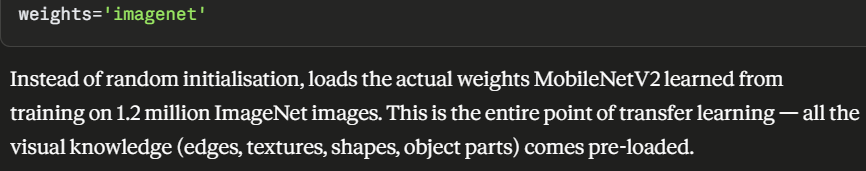

In [18]:
conv_base.summary()

Model: "mobilenetv2_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_4[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

In [15]:
# Pre-computing Feature Extractions from the Frozen MobileNetV2 Base
def get_features_and_labels(dataset):
    all_features = []                # Two empty lists to collect results batch by batch
    all_labels = []
    for images, labels in dataset:
        preprocessed_images = preprocess_input(images) 
        features = conv_base.predict(preprocessed_images, verbose=0)   # extracts features without training
        all_features.append(features)
        all_labels.append(labels)
    # Merges all batches into two single arrays — one for features, one for labels    
    return np.concatenate(all_features), np.concatenate(all_labels)

train_features, train_labels = get_features_and_labels(train_dataset)
val_features, val_labels = get_features_and_labels(validation_dataset)
test_features, test_labels = get_features_and_labels(test_dataset)
print("Done.")
print(train_features.shape)
print(train_labels.shape)

Done.
(7500, 7, 7, 1280)
(7500,)


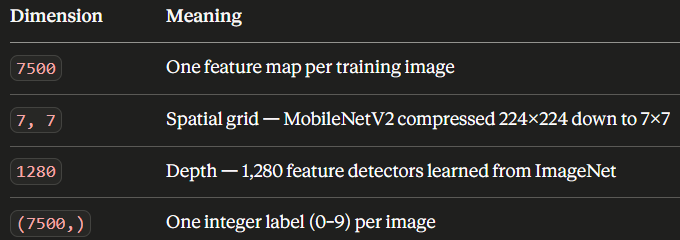  

By pre-computing once and saving the (7, 7, 1280) feature maps, your training loop only needs to update the lightweight classifier head (Dense 128 → Dropout → Dense 10). Training becomes significantly faster with no loss in accuracy.  
Without this approach, every training epoch would run all 7,500 images through the 2.2M frozen MobileNetV2 parameters — which never change — 30 times over. That is redundant computation repeated 30 times.

In [8]:
# Build custom classifier on top
model_fe = models.Sequential([
    layers.Input(shape=train_features.shape[1:]),  # input takes only (7, 7, 1280)
    layers.GlobalAveragePooling2D(),               # Reduces parameters massively! (7, 7, 1280)  →  (1280,)
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

model_fe.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 165,258 (645.54 KB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 0 (0.00 B)

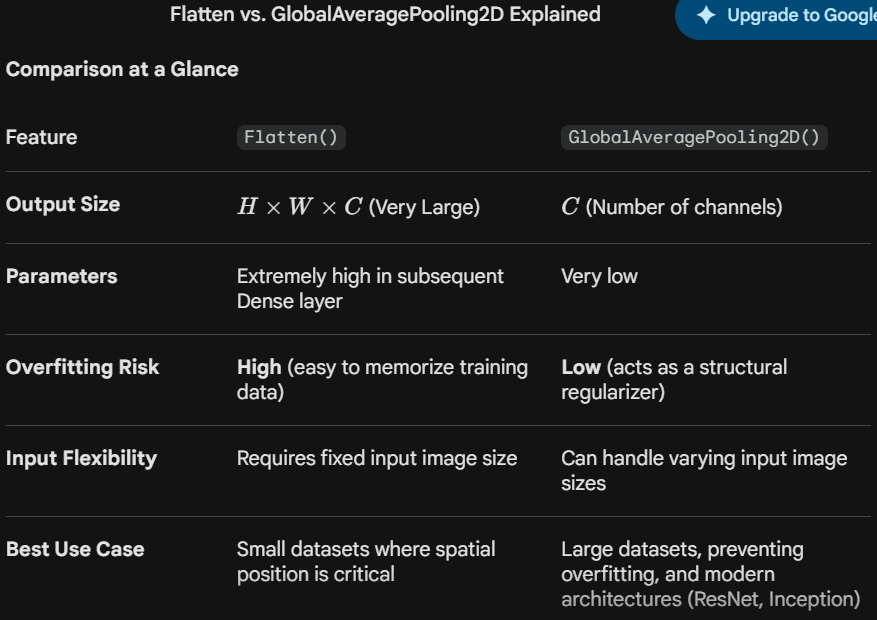

In [10]:
# compile with small learning rate
model_fe.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=2e-5), 
    loss='sparse_categorical_crossentropy',                         
    metrics=['acc']
)
history_fe = model_fe.fit(
    train_features,
    train_labels,
    epochs=EPOCHS,          
    batch_size=BATCH_SIZE,      
    validation_data=(val_features, val_labels)
)

Epoch 1/30


I0000 00:00:1778472973.478331    7969 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_33900__.14


375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - acc: 0.2585 - loss: 2.1073 - val_acc: 0.5070 - val_loss: 1.6719
Epoch 2/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - acc: 0.4912 - loss: 1.5595 - val_acc: 0.6430 - val_loss: 1.2782
Epoch 3/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - acc: 0.5920 - loss: 1.2666 - val_acc: 0.6895 - val_loss: 1.0635
Epoch 4/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.6451 - loss: 1.0998 - val_acc: 0.7190 - val_loss: 0.9393
Epoch 5/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - acc: 0.6780 - loss: 1.0006 - val_acc: 0.7440 - val_loss: 0.8601
Epoch 6/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - acc: 0.7081 - loss: 0.9069 - val_acc: 0.7545 - val_loss: 0.8093
Epoch 7/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - acc: 0.7256 - loss: 0.8548 - val_acc: 0.7635 - val_loss: 0.7718
Epoch 8/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - acc: 0.7237 - loss: 0.8158 - val_acc: 0.7715 - val_loss: 0.7411
Epoch 9/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - acc: 0.7451 -

In [33]:
model_fe.save('/mnt/c/Users/cheew/DLIR/Assignment/food_model_fe.keras')

In [11]:
test_loss, test_acc = model_fe.evaluate(test_features, test_labels)
print(f"\nTest Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - acc: 0.7780 - loss: 0.6373

Test Loss:     0.6373
Test Accuracy: 0.7780


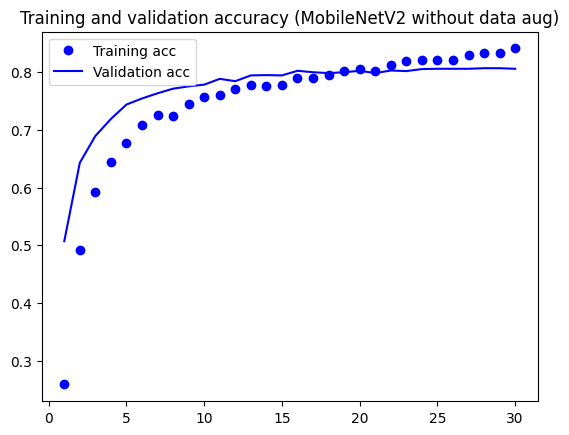

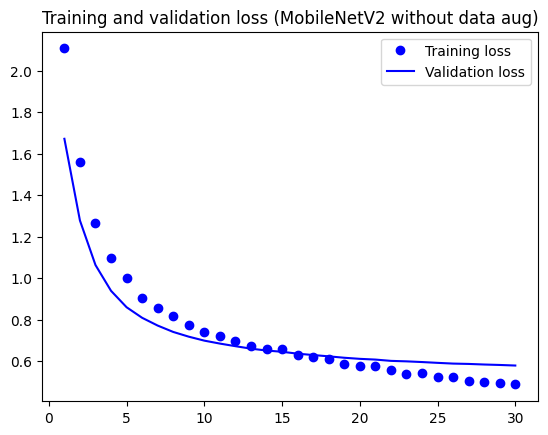

In [12]:
import matplotlib.pyplot as plt
%matplotlib inline

acc_fe = history_fe.history['acc']
val_acc_fe = history_fe.history['val_acc']
loss_fe = history_fe.history['loss']
val_loss_fe = history_fe.history['val_loss']

epochs = range(1, len(acc_fe) + 1)

plt.plot(epochs, acc_fe, 'bo', label='Training acc')
plt.plot(epochs, val_acc_fe, 'b', label='Validation acc')
plt.title('Training and validation accuracy (MobileNetV2 without data aug)')
plt.legend()

plt.figure()

plt.plot(epochs, loss_fe, 'bo', label='Training loss')
plt.plot(epochs, val_loss_fe, 'b', label='Validation loss')
plt.title('Training and validation loss (MobileNetV2 without data aug)')
plt.legend()

plt.show()

Observations:
Training accuracy climbs steadily to 82% while Validation accuracy plateauing around 80%.   

Training loss has consistent downward trend. Validation loss trends downward and settled about 0.58, barely decreasing.

There is mild overfitting 

### Model 2b - Feature extraction with data augmentation

In [3]:
import tensorflow as tf
from keras.applications import MobileNetV2
from keras.applications.mobilenet_v2 import preprocess_input
from keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import os

In [4]:
base_dir    = '/mnt/c/Users/cheew/DLIR/Assignment/food'
train_dir   = os.path.join(base_dir, 'train')
validation_dir     = os.path.join(base_dir, 'validation')
test_dir    = os.path.join(base_dir, 'test')

IMG_SIZE    = (224, 224)
BATCH_SIZE  = 20     
NUM_CLASSES = 10
EPOCHS      = 50


In [5]:
data_augmentation_layers = [
    layers.RandomFlip("horizontal"),
    layers.RandomRotation([-0.1, 0.1], fill_mode='nearest'),    # Randomly rotates the image between -10% and +10% of a full 360deg turn
    layers.RandomZoom(0.2, 0.2, fill_mode='nearest'),           # Randomly zooms in or out by up to 20% on both height and width independently
    layers.RandomTranslation([-0.2, 0.2], [-0.2, 0.2], fill_mode='nearest') # Randomly shifts the image up to 20% in any direction — left/right and up/down
]

# For train — augment then preprocess
# augment on raw pixels, then scale
def data_augmentation(images, targets):
    for layer in data_augmentation_layers:
        images = layer(images)
    preprocessed_images = preprocess_input(images)
    return preprocessed_images, targets

# For validation and test — preprocess only, no augment
def data_preprocess(images, targets):
    preprocessed_images = preprocess_input(images)
    return preprocessed_images, targets

I0000 00:00:1778567623.458149    2239 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3536 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:02:00.0, compute capability: 8.9


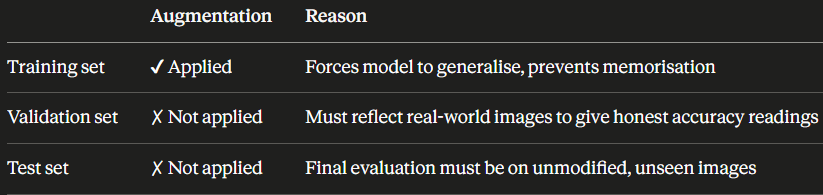

In [12]:
# Apply Augmentation to Datasets
augmented_train_dataset = train_dataset.map(
    data_augmentation, num_parallel_calls=8
)

validation_dataset_processed = validation_dataset.map(
    data_preprocess, num_parallel_calls=8
)

test_dataset_processed = test_dataset.map(
    data_preprocess, num_parallel_calls=8
)

print("augmented_train_dataset ready:", type(augmented_train_dataset))
print("validation_dataset_processed ready:  ", type(validation_dataset_processed))
print("test_dataset_processed ready: ", type(test_dataset_processed))

augmented_train_dataset ready: <class 'tensorflow.python.data.ops.map_op._ParallelMapDataset'>
validation_dataset_processed ready:   <class 'tensorflow.python.data.ops.map_op._ParallelMapDataset'>
test_dataset_processed ready:  <class 'tensorflow.python.data.ops.map_op._ParallelMapDataset'>


In [16]:
print("conv_base trainable:", conv_base.trainable)
model_fe_aug = models.Sequential([
    conv_base,
    layers.GlobalAveragePooling2D(),       
    layers.Dense(128, activation='relu'),  
    layers.Dropout(0.3),                   # ← added to reduce overfitting
    layers.Dense(NUM_CLASSES, activation='softmax')
])

model_fe_aug.summary()

conv_base trainable: False


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [17]:
model_fe_aug.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=2e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['acc']
)

In [30]:
history_fe_aug = model_fe_aug.fit(
    augmented_train_dataset,
    epochs=EPOCHS,
    validation_data=validation_dataset_processed
)

Epoch 1/50


I0000 00:00:1778475193.469464    7970 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_105819__.119


375/375 ━━━━━━━━━━━━━━━━━━━━ 19s 38ms/step - acc: 0.1756 - loss: 2.3316 - val_acc: 0.3475 - val_loss: 1.9677
Epoch 2/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - acc: 0.3691 - loss: 1.8821 - val_acc: 0.5400 - val_loss: 1.5932
Epoch 3/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 18s 48ms/step - acc: 0.4999 - loss: 1.5661 - val_acc: 0.6155 - val_loss: 1.3214
Epoch 4/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 14s 38ms/step - acc: 0.5560 - loss: 1.3792 - val_acc: 0.6685 - val_loss: 1.1437
Epoch 5/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 16s 41ms/step - acc: 0.6043 - loss: 1.2381 - val_acc: 0.6940 - val_loss: 1.0342
Epoch 6/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 17s 42ms/step - acc: 0.6248 - loss: 1.1494 - val_acc: 0.7155 - val_loss: 0.9556
Epoch 7/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 15s 40ms/step - acc: 0.6453 - loss: 1.0867 - val_acc: 0.7245 - val_loss: 0.9034
Epoch 8/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 17s 44ms/step - acc: 0.6576 - loss: 1.0436 - val_acc: 0.7385 - val_loss: 0.8670
Epoch 9/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 16s 42ms/st

In [18]:
model_fe_aug.save('/mnt/c/Users/cheew/DLIR/Assignment/food_model_fe_aug.keras')

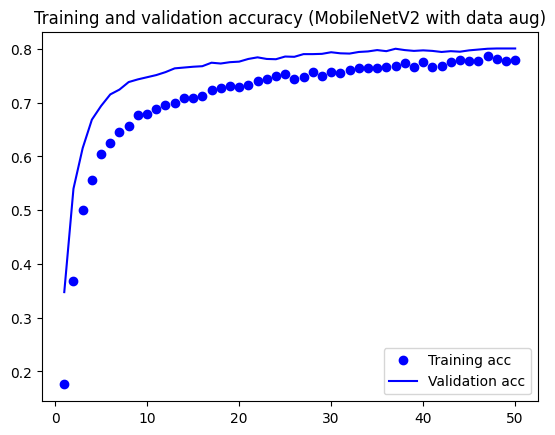

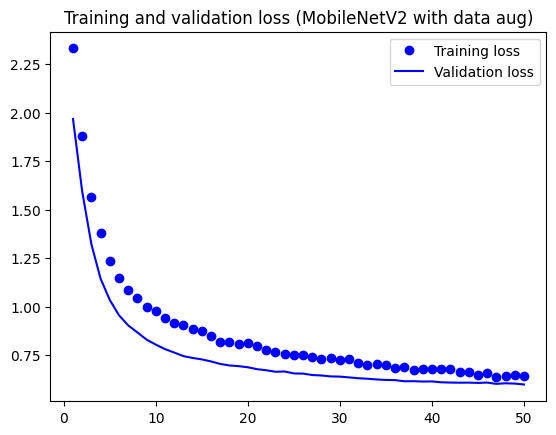

In [32]:
import matplotlib.pyplot as plt
%matplotlib inline

acc_fe_aug = history_fe_aug.history['acc']
val_acc_fe_aug = history_fe_aug.history['val_acc']
loss_fe_aug = history_fe_aug.history['loss']
val_loss_fe_aug = history_fe_aug.history['val_loss']

epochs = range(1, len(acc_fe_aug) + 1)

plt.plot(epochs, acc_fe_aug, 'bo', label='Training acc')
plt.plot(epochs, val_acc_fe_aug, 'b', label='Validation acc')
plt.title('Training and validation accuracy (MobileNetV2 with data aug)')
plt.legend()

plt.figure()

plt.plot(epochs, loss_fe_aug, 'bo', label='Training loss')
plt.plot(epochs, val_loss_fe_aug, 'b', label='Validation loss')
plt.title('Training and validation loss (MobileNetV2 with data aug)')
plt.legend()

plt.show()

Training and Validation accuracy track each other closely and converged around 77-78%, both curves still rising slightly at Epoch 50. Train-Validation gap is minimal, overfitting is resolved.

Training and validation loss tracked each other closely and both descresed consistently and converged at around 65%.  
The shape of this loss curve represent a well-regularised model.

In [5]:
import keras
model_fe_aug = keras.models.load_model('/mnt/c/Users/cheew/DLIR/Assignment/food_model_fe_aug.keras')

# Note that the test data should not be augmented!
# Creates a function that preprocess testing dataset
def data_preprocess(images, targets):
    preprocessed_images = preprocess_input(images)
    return preprocessed_images, targets

# Maps this function into the dataset, num_parallel_calls activates number of CPU Core to do the processing
test_dataset = train_dataset.map(
    data_preprocess, num_parallel_calls=8
)

test_loss, test_acc = model_fe_aug.evaluate(test_dataset, steps=50)
print('test acc:', test_acc)

I0000 00:00:1778571676.858724   70315 service.cc:153] XLA service 0x7ecc9c05b010 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778571676.858761   70315 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9 (Driver: 13.1.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.19.0)
I0000 00:00:1778571676.896955   70315 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1778571677.295591   70315 cuda_dnn.cc:461] Loaded cuDNN version 91900
E0000 00:00:1778571681.311786   70315 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


 1/50 ━━━━━━━━━━━━━━━━━━━━ 10:45 13s/step - acc: 0.8500 - loss: 0.6124

I0000 00:00:1778571688.770446   70315 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


50/50 ━━━━━━━━━━━━━━━━━━━━ 14s 21ms/step - acc: 0.8420 - loss: 0.4727
test acc: 0.8420000076293945


In [6]:
# Evaluate with test dataset

model2 = keras.models.load_model('/mnt/c/Users/cheew/DLIR/Assignment/food_model_fe_aug.keras')

test_loss2, test_acc2 = model2.evaluate(test_dataset)
print(f"Model 2 (Pre-trained) Test Accuracy: {test_acc2:.4f}")

375/375 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step - acc: 0.8241 - loss: 0.5149
Model 2 (Pre-trained) Test Accuracy: 0.8241


## Model 2c - Fine-tuning

MobileNetV2 has 16 blocks. For fine-tuning,:  

* Keep frozen (blocks 1–12): low-level features like edges and textures — generic, not food-specific  
* Unfreeze (blocks 13–16 + Conv_1): high-level features — more task-specific, worth fine-tuning for food classification  

In [38]:
# Unfreeze the entire conv_base first
conv_base.trainable = True

# Freeze all layers up to block_13
# Fine-tune only from block_13 onwards

freeze = True
for layer in conv_base.layers:
    if layer.name == 'block_13_expand':
        freeze = False          # start unfreezing from here
    layer.trainable = not freeze

# Verify which layers are now trainable
print(f"{'Layer':<40} {'Trainable'}")
print("-" * 50)
for layer in conv_base.layers:
    print(f"{layer.name:<40} {layer.trainable}")

model.summary()

Layer                                    Trainable
--------------------------------------------------
input_layer_4                            False
Conv1                                    False
bn_Conv1                                 False
Conv1_relu                               False
expanded_conv_depthwise                  False
expanded_conv_depthwise_BN               False
expanded_conv_depthwise_relu             False
expanded_conv_project                    False
expanded_conv_project_BN                 False
block_1_expand                           False
block_1_expand_BN                        False
block_1_expand_relu                      False
block_1_pad                              False
block_1_depthwise                        False
block_1_depthwise_BN                     False
block_1_depthwise_relu                   False
block_1_project                          False
block_1_project_BN                       False
block_2_expand                           False
block

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,753,760 (10.50 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 330,518 (1.26 MB)

In [39]:
# Recompile with a much lower learning rate
# Fine-tuning needs ~10x lower lr than feature extraction
model_fe_aug.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=2e-6),  # 10x lower than before
    loss='sparse_categorical_crossentropy',
    metrics=['acc']
)

In [40]:
history_ft = model_fe_aug.fit(
    augmented_train_dataset,
    epochs=30,                              # fewer epochs needed
    validation_data=validation_dataset_processed
)

Epoch 1/30


I0000 00:00:1778482436.604456    7964 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_221778__.119


375/375 ━━━━━━━━━━━━━━━━━━━━ 21s 41ms/step - acc: 0.7844 - loss: 0.6325 - val_acc: 0.8005 - val_loss: 0.5993
Epoch 2/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 12s 31ms/step - acc: 0.7819 - loss: 0.6363 - val_acc: 0.8010 - val_loss: 0.5990
Epoch 3/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 15s 40ms/step - acc: 0.7823 - loss: 0.6340 - val_acc: 0.8015 - val_loss: 0.5991
Epoch 4/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - acc: 0.7887 - loss: 0.6360 - val_acc: 0.8020 - val_loss: 0.5990
Epoch 5/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 14s 37ms/step - acc: 0.7889 - loss: 0.6283 - val_acc: 0.8020 - val_loss: 0.5993
Epoch 6/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 15s 39ms/step - acc: 0.7871 - loss: 0.6313 - val_acc: 0.8020 - val_loss: 0.5984
Epoch 7/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 15s 39ms/step - acc: 0.7821 - loss: 0.6376 - val_acc: 0.8025 - val_loss: 0.5986
Epoch 8/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 15s 40ms/step - acc: 0.7844 - loss: 0.6375 - val_acc: 0.8030 - val_loss: 0.5980
Epoch 9/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 14s 38ms/st

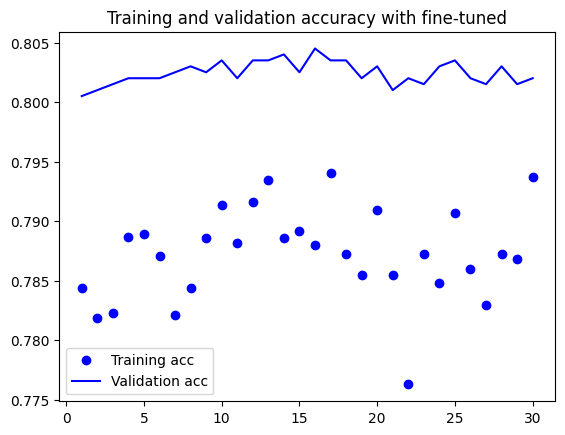

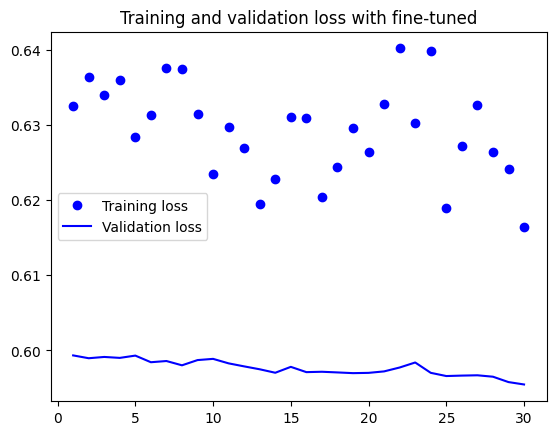

In [41]:
acc_ft = history_ft.history['acc']
val_acc_ft = history_ft.history['val_acc']
loss_ft = history_ft.history['loss']
val_loss_ft = history_ft.history['val_loss']

epochs = range(1, len(acc_ft) + 1)

plt.plot(epochs, acc_ft, 'bo', label='Training acc')
plt.plot(epochs, val_acc_ft, 'b', label='Validation acc')
plt.title('Training and validation accuracy with fine-tuned')
plt.legend()

plt.figure()

plt.plot(epochs, loss_ft, 'bo', label='Training loss')
plt.plot(epochs, val_loss_ft, 'b', label='Validation loss')
plt.title('Training and validation loss with fine-tuned')
plt.legend()

plt.show()

Observations:
* The reasons Training accuracy less than validation accuracy:
* Augmentation is applied to training images only, artificially lowering training accuracy
* Dropout (0.3) is active during training but disabled during validation — makes training harder

* The validation accuracy barely move from 0.80 - 0.804 over 30 epochs, the model has reached a plateau
* No evidence of overfitting but appears slightly underfitted.

### The below iteration is for self-experiement only, not included in the assignment report

In [42]:
# increase the learning rate from 2e-6 to 1e-5
model_fe_aug.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),  # try 1e-5 instead of 2e-6
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_fine = model_fe_aug.fit(
    augmented_train_dataset,
    epochs=30,
    validation_data=val_dataset_processed
)

Epoch 1/30


I0000 00:00:1778483683.767782    7967 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_287551__.119


375/375 ━━━━━━━━━━━━━━━━━━━━ 21s 43ms/step - accuracy: 0.7931 - loss: 0.6179 - val_accuracy: 0.8030 - val_loss: 0.5962
Epoch 2/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 14s 38ms/step - accuracy: 0.7853 - loss: 0.6196 - val_accuracy: 0.8040 - val_loss: 0.5962
Epoch 3/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 13s 35ms/step - accuracy: 0.7937 - loss: 0.6208 - val_accuracy: 0.8050 - val_loss: 0.5921
Epoch 4/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 15s 40ms/step - accuracy: 0.7903 - loss: 0.6138 - val_accuracy: 0.8050 - val_loss: 0.5940
Epoch 5/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 16s 43ms/step - accuracy: 0.7877 - loss: 0.6208 - val_accuracy: 0.8035 - val_loss: 0.5922
Epoch 6/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 17s 46ms/step - accuracy: 0.7905 - loss: 0.6255 - val_accuracy: 0.8050 - val_loss: 0.5933
Epoch 7/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 16s 42ms/step - accuracy: 0.7888 - loss: 0.6202 - val_accuracy: 0.8015 - val_loss: 0.5944
Epoch 8/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 16s 42ms/step - accuracy: 0.7917 - loss: 0.6092 - val_accurac

In [49]:
#save model
model_fe_aug.save('/mnt/c/Users/cheew/DLIR/Assignment/food_model_fine_tuned.keras')

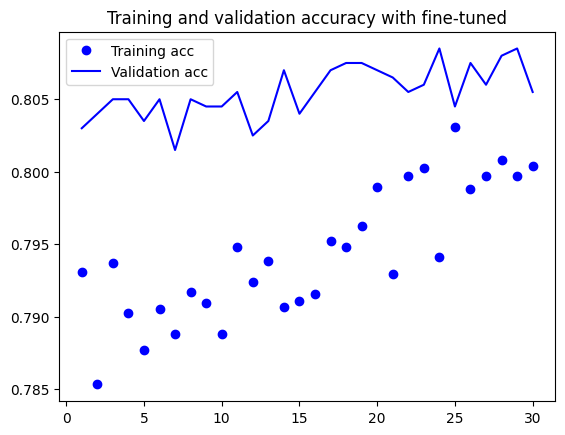

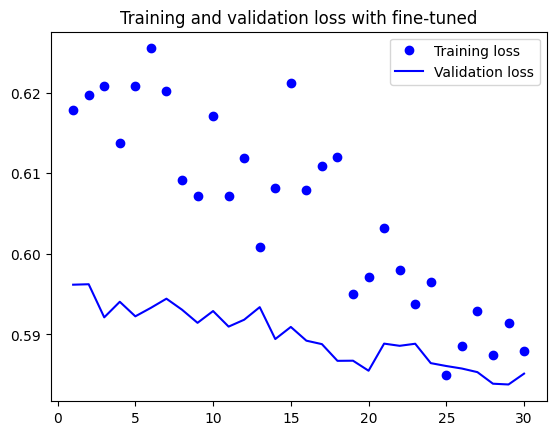

In [47]:
acc_fine = history_fine.history['accuracy']
val_acc_fine = history_fine.history['val_accuracy']
loss_fine = history_fine.history['loss']
val_loss_fine = history_fine.history['val_loss']

epochs = range(1, len(acc_fine) + 1)

plt.plot(epochs, acc_fine, 'bo', label='Training acc')
plt.plot(epochs, val_acc_fine, 'b', label='Validation acc')
plt.title('Training and validation accuracy with fine-tuned')
plt.legend()

plt.figure()

plt.plot(epochs, loss_fine, 'bo', label='Training loss')
plt.plot(epochs, val_loss_fine, 'b', label='Validation loss')
plt.title('Training and validation loss with fine-tuned')
plt.legend()

plt.show()

By lowering the learning rate to 1e-5, this model perform better than the previous run. The validation accuracy has improved to 0.809 over 30 epochs. The training accuracy converge towards validation accuracy, closing the gap.

For the loss curves, both clearly trending downwards

## Evaluate

In [11]:
import keras
model2 = keras.models.load_model('/mnt/c/Users/cheew/DLIR/Assignment/food_model_fe_aug.keras')

test_loss2, test_acc2 = model2.evaluate(test_dataset)
print(f"Model 2 (Pre-trained) Test Accuracy: {test_acc2:.4f}")

I0000 00:00:1778567807.137983    2317 service.cc:153] XLA service 0x72191c05b4b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778567807.138011    2317 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9 (Driver: 13.1.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.19.0)
I0000 00:00:1778567807.166488    2317 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1778567807.493263    2317 cuda_dnn.cc:461] Loaded cuDNN version 91900
E0000 00:00:1778567811.621682    2317 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


 3/25 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - acc: 0.0972 - loss: 3.4953

I0000 00:00:1778567815.328435    2317 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - acc: 0.1060 - loss: 3.5049
Model 2 (Pre-trained) Test Accuracy: 0.1060
